# Imports

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [4]:
import os
import sys

sys.path.append(os.path.realpath(os.path.join(os.getcwd(), "..")))
sys.path.append(os.path.realpath(os.path.join(os.getcwd(), "..", 'LoadForecastingAttacks')))
# sys.path.append('LoadForecastingAttacks')

import ERCOTProcessor
import WeatherProcessing
import FeatureEngineering
import ForecastingHelpers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# import sklearn
from multiprocessing import Pool, Manager
from copy import deepcopy
import random



# from PreprocessingFunctions import *

import mapie

# from mapie.regression import MapieRegressor



%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 125

# Drift Simulation

Assuming we only train on 2002 to 2017, how many timesteps will it take for each of the models to drift from an acceptable range?

In [5]:
parquet_file = "../ercot_data/full_df.parquet"
use_saved = True

if not use_saved or not (os.path.exists(parquet_file)):
	# Does not like processing between 2002-2024 in one go, split to allow for optimization
	ercot_df_pt1 = ERCOTProcessor.fileprocessing(2002,2016)
	ercot_df_pt2 = ERCOTProcessor.fileprocessing(2016,2024)
	ercot_df = pd.concat([ercot_df_pt1, ercot_df_pt2])

	# Process weather data
	filename = 'weather_20022024.csv'
	weather_df = pd.read_csv(filename).drop('Unnamed: 0', axis=1)
	weather_df.columns = ['time', 'temp', 'humd', 'wnsp', 'cond']
	weather_df.loc[:,'time'] = weather_df['time'].apply(lambda x: pd.to_datetime(x))
	weather_df = weather_df.set_index('time')
	weather_df.head()

	# Concat weather and ERCOT data and deduplicate any values
	full_df = FeatureEngineering.feature_engineering(weather_df, ercot_df)
	full_df = full_df.drop_duplicates(subset=None, keep="last", inplace=False)
	full_df = full_df[~full_df.index.duplicated()]


	full_df.head()

	full_df.to_parquet(parquet_file)

else:
	full_df = pd.read_parquet(parquet_file)
	print(full_df.head())
	print(full_df.info())

                         load      temp  humd      wnsp  tstorm  clear  fog  \
time                                                                          
2002-01-01 00:00:00  0.151091  0.262626  0.64  0.282828     0.0    1.0  0.0   
2002-01-01 01:00:00  0.149039  0.262626  0.57  0.323232     0.0    1.0  0.0   
2002-01-01 02:00:00  0.144042  0.262626  0.57  0.323232     0.0    1.0  0.0   
2002-01-01 03:00:00  0.141398  0.262626  0.57  0.242424     0.0    1.0  0.0   
2002-01-01 04:00:00  0.143424  0.252525  0.61  0.323232     0.0    1.0  0.0   

                     rain  cloud  snow  weekday  sin_hour  cos_hour  
time                                                                 
2002-01-01 00:00:00   0.0    0.0   0.0        1  0.000000  1.000000  
2002-01-01 01:00:00   0.0    0.0   0.0        1  0.258819  0.965926  
2002-01-01 02:00:00   0.0    0.0   0.0        1  0.500000  0.866025  
2002-01-01 03:00:00   0.0    0.0   0.0        1  0.707107  0.707107  
2002-01-01 04:00:00   0.0 

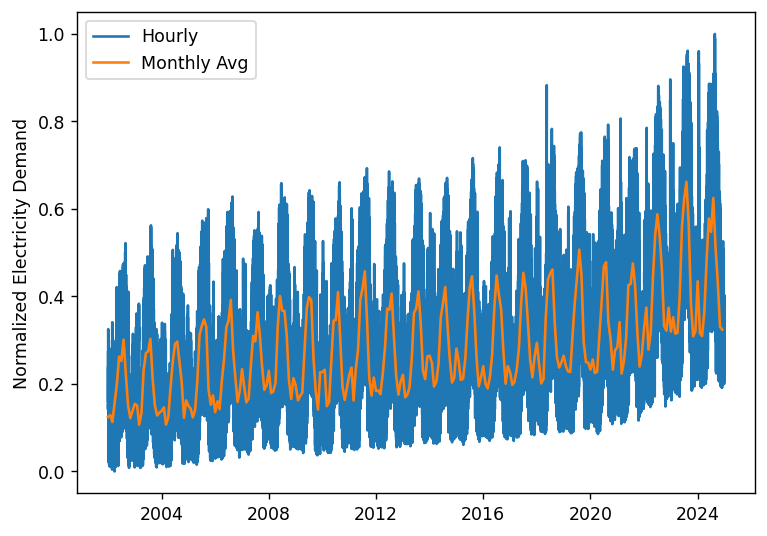

In [6]:
# Plot a monthly rolling average versus the true hourly value
monthly_norm = full_df['load'].resample('MS').mean().bfill()
plt.plot(full_df['load'], label='Hourly')
plt.plot(monthly_norm, label='Monthly Avg')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

# MLP Regression

In [7]:
hourly_res_norm = ForecastingHelpers.hourlyresiduals(full_df)

/home/kafoap/Documents/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/ForecastingHelpers.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hourly_res_norm['load'] = df_norm['load'].groupby(pd.Grouper(freq='M')).transform(lambda x: x - x.mean())


In [8]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

## MLP Regression Grid Search

In [9]:
def compute_mae(y, yhat):
    """given predicted and observed values, computes mean absolute error"""
    return np.mean(np.abs(yhat - y))

def forecast(model, exog, y_init):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = model.predict(Xi_te)[0]
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat.append(model.predict(Xi_te)[0])
    return np.array(yhat)
def weekly_forecast(model, exog, y_init):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        yhat.append(forecast(model, exog_i, yi))
    return np.hstack(yhat)

In [7]:
# def get_mlp_mae(params):
#     hl, a, lr, mi = params
#     mod = MLPRegressor(hidden_layer_sizes=hl, alpha=a, learning_rate_init=lr, max_iter=mi)
#     mod.fit(X_tr, y_tr)
#     pred_val = weekly_forecast(mod, exog_val, y_init_val)
#     mae = compute_mae(y_val, pred_val)
#     return {'hl': hl, 'a': a, 'lr': lr, 'mi': mi, 'mae': mae}

# # # define potential sets of hyperparameters
# # hidden_layer_sizes = [(100,), (500,), (100, 10,), (100, 100,)]
# # alpha = [0.0001, 0.00001, 0.001]
# # learning_rate = [0.0001, 0.001, 0.01]
# # max_iter = [200, 1000, 10000]

# # define potential sets of hyperparameters
# hidden_layer_sizes = [(100,), (500,), (100, 10,), (100, 100,)]
# alpha = [0.0001, 0.00001, 0.001]
# learning_rate = [0.0001, 0.001, 0.01]
# max_iter = [200, 1000, 10000]


# # create a list of all combinations of hyperparameters
# param_list = [(hl, a, lr, mi) for hl in hidden_layer_sizes for a in alpha for lr in learning_rate for mi in max_iter]

# def parallel_mlp_search(param_list, result_list):
#     with Pool(processes=(os.cpu_count()-1)) as pool:
#         results = pool.map(get_mlp_mae, param_list)
#         result_list.extend(results)

# if __name__ == '__main__':
#     manager = Manager()
#     result_list = manager.list()

#     parallel_mlp_search(param_list, result_list)
    
#     # convert result_list to DataFrame
#     grid_search = pd.DataFrame(list(result_list))

#     # display best hyperparameters based on grid search
#     print(grid_search.sort_values('mae').head(1))
#     grid_mlp = grid_search.sort_values('mae').head(1)
    

In [10]:
# best hyperparamters
# hl, a, lr, mi  = grid_mlp['hl'].values[0], grid_mlp['a'].values[0], grid_mlp['lr'].values[0], grid_mlp['mi'].values[0]
hl, a, lr, mi  = (100, 100), 0.001, 0.0001, 1000

# train model and get predictions
mod_mlp = MLPRegressor(hidden_layer_sizes=hl, alpha=a, learning_rate_init=lr, max_iter=mi)
mod_mlp.fit(X_tr, y_tr)

MLPRegressor(alpha=0.001, hidden_layer_sizes=(100, 100),
             learning_rate_init=0.0001, max_iter=1000)

# Modify Weights

In [20]:
med_drifts = []
high_drifts = []
noises = []

for _ in range(100):
	# mod_mlp_modified = sklearn.base.clone(mod_mlp)
	mod_mlp_modified = deepcopy(mod_mlp)
	weights = mod_mlp_modified.coefs_

	# Add random noise to all weights
	noise_scale = random.uniform(0.0, .02)
	# noise_scale = .01  # Adjust this value as needed

	for i in range(len(weights)):
		# Xavier Initialization, scaled down
		noise_level = noise_scale * np.sqrt(2 / (weights[i].shape[0] + weights[i].shape[1]))
		# print(noise_level)
		noise = np.random.normal(0, noise_level, weights[i].shape)
		weights[i] += noise
		# print(weights[i].shape)
		# print(weights[i].shape[0])

	# Update the model with modified weights
	mod_mlp_modified.coefs_ = weights

	pred = weekly_forecast(mod_mlp_modified, exog_val, y_init_val)
	pred_te = weekly_forecast(mod_mlp_modified, exog_te, y_init_te)

	# Convert prediction and confidence interval for validation and testing datasets to Pandas Dataframes 
	# to be used to find the deviation of the confidence interval width
	pred_df = pd.DataFrame(data=pred, index=yp_val.index, columns=['load'])
	pred_test = pd.DataFrame(data=pred_te, index=yp_te.index, columns=['load'])
	preds_mlp = pd.concat([pred_df, pred_test])
	# ci = pd.concat([pred_ci, pred_ci_te])
	preds_np = preds_mlp['load']
	normals = pd.concat([yp_val, yp_te])

	# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
	diverge = ForecastingHelpers.calculateKLDivergence(yp_te,preds_mlp['load'])
	med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, yp_te)


	load_min, load_max = full_df['load'].min(), full_df['load'].max()
	temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
	wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()


	# best hyperparameters from grid search
	best_monthly_order = (1,1,1)
	best_monthly_seas_order = (0,1,1,12)


	# monthly average forecasts
	train_m = monthly_norm[:'2016']
	test_m = monthly_norm['2017':]
	model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit(maxiter=1000, disp=False)
	# model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit(disp=False)
	forecast_m = model_m.get_forecast(steps=len(test_m))
	pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)


	# dataframe of montly forecasts
	m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

	mlp_norm_df = pd.DataFrame({'h_norm':pred_test['load'], 'month':test.index.month, 'year':test.index.year})
	pred_mlp_norm_df = mlp_norm_df.merge(m_norm_df, on=['month','year'])
	pred_mlp_norm = pd.Series((pred_mlp_norm_df['m_norm'] + pred_mlp_norm_df['h_norm']).values, index=test.index)
	pred_mlp = pred_mlp_norm * (load_max - load_min) + load_min

	# Downsample to a monthly basis to reduce KL and PSI sensitivity
	sampled_pred = pred_mlp.resample('MS').mean().bfill()

	# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
	diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
	med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)

	# med_drift, high_drift

	print(f"{med_drift=}")
	print(f"{high_drift=}")
	med_drifts.append(med_drift)
	high_drifts.append(high_drift)
	noises.append(noise_scale)


/opt/miniforge3/envs/ray_pip/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


med_drift=Timestamp('2021-12-01 00:00:00')
high_drift=Timestamp('2023-03-01 00:00:00')


/opt/miniforge3/envs/ray_pip/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


med_drift=Timestamp('2018-05-01 00:00:00')
high_drift=Timestamp('2020-11-01 00:00:00')


/opt/miniforge3/envs/ray_pip/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/miniforge3/envs/ray_pip/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


med_drift=Timestamp('2017-09-01 00:00:00')
high_drift=Timestamp('2019-04-01 00:00:00')


/opt/miniforge3/envs/ray_pip/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


med_drift=Timestamp('2018-10-01 00:00:00')
high_drift=Timestamp('2022-02-01 00:00:00')
med_drift=Timestamp('2017-02-01 00:00:00')
high_drift=Timestamp('2017-08-01 00:00:00')


/opt/miniforge3/envs/ray_pip/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


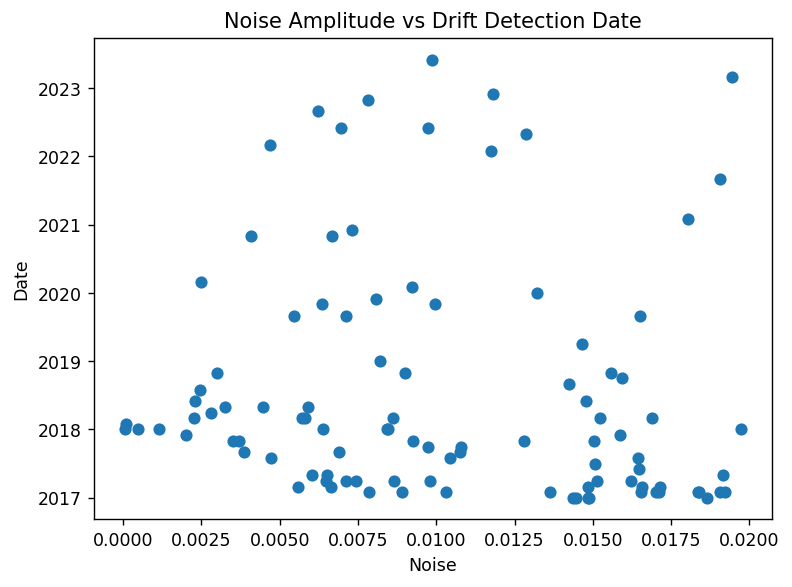

In [23]:
# plt.scatter(noises, med_drifts)
plt.scatter(noises, high_drifts)

plt.xlabel('Noise')
plt.ylabel('Date')
plt.title('Noise Amplitude vs Drift Detection Date')

plt.show()

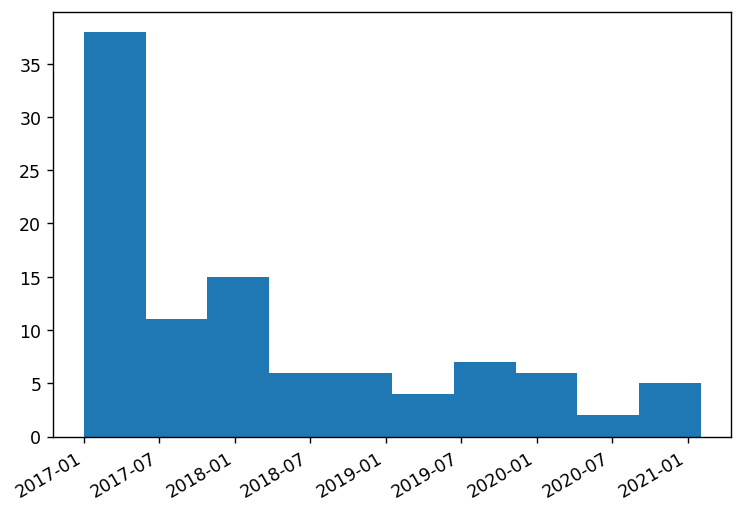

In [ ]:
plt.hist(med_drifts)
# plt.hist(high_drifts)
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Histogram of Drift')
plt.gcf().autofmt_xdate()
plt.show()

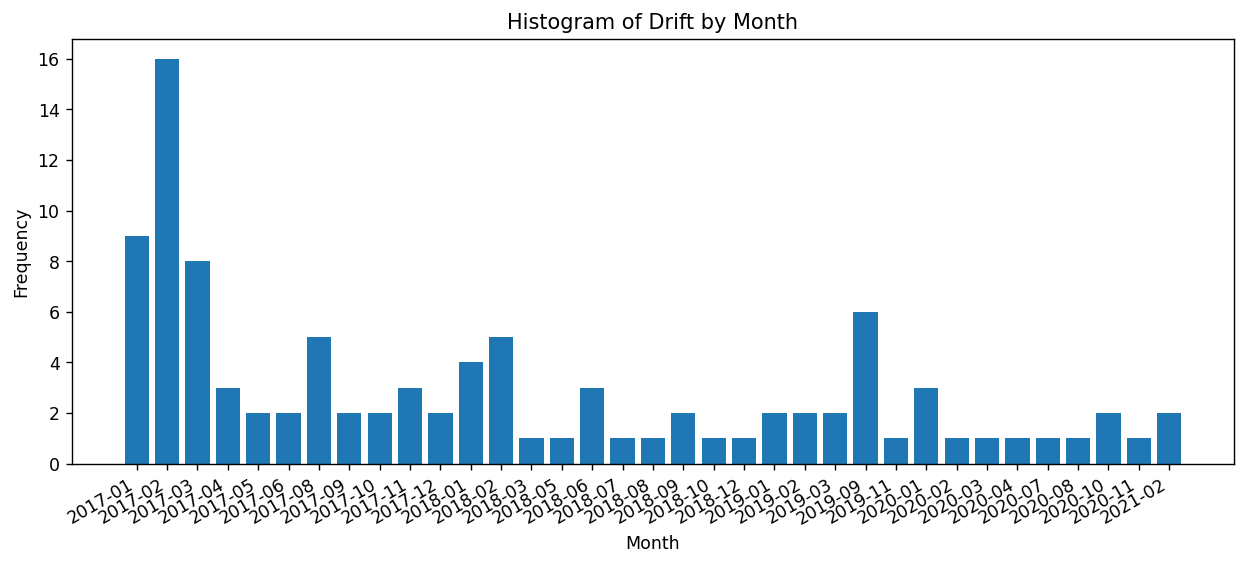

In [28]:
# df = pd.DataFrame(high_drifts, columns=['date'])
df = pd.DataFrame(med_drifts, columns=['date'])

# Convert date column to datetime if not already
df['date'] = pd.to_datetime(df['date'])
# Extract month and year for grouping
df['year_month'] = df['date'].dt.to_period('M')

# Calculate the frequency of each month
monthly_counts = df['year_month'].value_counts().sort_index()

# Plot the histogram
plt.figure(figsize=(12, 5))
plt.bar(monthly_counts.index.astype(str), monthly_counts.values)
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Histogram of Drift by Month')
# plt.xticks(rotation=45)
plt.gcf().autofmt_xdate()

plt.show()

In [11]:
# mod_mlp_modified = sklearn.base.clone(mod_mlp)
mod_mlp_modified = deepcopy(mod_mlp)
weights = mod_mlp_modified.coefs_

# Add random noise to all weights
noise_scale = .007  # Adjust this value as needed

for i in range(len(weights)):
    # Xavier Initialization, scaled down
    noise_level = noise_scale * np.sqrt(2 / (weights[i].shape[0] + weights[i].shape[1]))
    print(noise_level)
    noise = np.random.normal(0, noise_level, weights[i].shape)
    weights[i] += noise
    print(weights[i].shape)
    print(weights[i].shape[0])

# Update the model with modified weights
mod_mlp_modified.coefs_ = weights

0.0009312661473328351
(13, 100)
13
0.0007000000000000001
(100, 100)
100
0.0009850365626224086
(100, 1)
100


In [12]:
pred = weekly_forecast(mod_mlp_modified, exog_val, y_init_val)
pred_te = weekly_forecast(mod_mlp_modified, exog_te, y_init_te)

In [13]:
# Convert prediction and confidence interval for validation and testing datasets to Pandas Dataframes 
# to be used to find the deviation of the confidence interval width
pred_df = pd.DataFrame(data=pred, index=yp_val.index, columns=['load'])
pred_test = pd.DataFrame(data=pred_te, index=yp_te.index, columns=['load'])
preds_mlp = pd.concat([pred_df, pred_test])
# ci = pd.concat([pred_ci, pred_ci_te])
preds_np = preds_mlp['load']
normals = pd.concat([yp_val, yp_te])

In [14]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(yp_te,preds_mlp['load'])
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, yp_te)
med_drift

Timestamp('2017-01-02 17:00:00')

In [15]:
# PSI, which is a deviation of KL divergence can be used to determe drift, it is the symmetric version of KL divergence.
psi = ForecastingHelpers.calculatePSI(yp_te, preds_mlp['load'])
med_PSI, high_PSI = ForecastingHelpers.testPSI(psi, yp_te)
med_PSI

/opt/miniforge3/envs/ray_pip/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Timestamp('2017-01-03 18:00:00')

Calculate KL Divergence for Monthly Forecasts to Compare to SARIMA

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

load_min, load_max = full_df['load'].min(), full_df['load'].max()
temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()


# best hyperparameters from grid search
best_monthly_order = (1,1,1)
best_monthly_seas_order = (0,1,1,12)


# monthly average forecasts
train_m = monthly_norm[:'2016']
test_m = monthly_norm['2017':]
model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit()
forecast_m = model_m.get_forecast(steps=len(test_m))
pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)

# baseline hourly residual forecasts
idx = test.index[::168]
idx = idx.append(pd.DatetimeIndex(['2017-12-31 23']))
pred_base = pd.Series(np.hstack([y_init_te, yp_te.iloc[-1]]), index=idx)
pred_base = pred_base.resample('H').ffill().values

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -2.01056D+00    |proj g|=  8.29089D+00

At iterate    5    f= -2.03318D+00    |proj g|=  7.34601D-02

At iterate   10    f= -2.03421D+00    |proj g|=  2.18785D+00

At iterate   15    f= -2.04557D+00    |proj g|=  2.69455D-01

At iterate   20    f= -2.04593D+00    |proj g|=  8.90686D-01

At iterate   25    f= -2.06545D+00    |proj g|=  4.88175D+00

At iterate   30    f= -2.09906D+00    |proj g|=  1.05391D-01

At iterate   35    f= -2.10029D+00    |proj g|=  1.35909D-01

At iterate   40    f= -2.10066D+00    |proj g|=  5.84915D-01

At iterate   45    f= -2.10862D+00    |proj g|=  5.40700D-01

At iterate   50    f= -2.11025D+00    |proj g|=  4.46482D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/opt/miniforge3/envs/ray_pip/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_950352/579075919.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pred_base = pred_base.resample('H').ffill().values


In [17]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

mlp_norm_df = pd.DataFrame({'h_norm':pred_test['load'], 'month':test.index.month, 'year':test.index.year})
pred_mlp_norm_df = mlp_norm_df.merge(m_norm_df, on=['month','year'])
pred_mlp_norm = pd.Series((pred_mlp_norm_df['m_norm'] + pred_mlp_norm_df['h_norm']).values, index=test.index)
pred_mlp = pred_mlp_norm * (load_max - load_min) + load_min

In [18]:
# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_pred = pred_mlp.resample('MS').mean().bfill()

In [19]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift

Timestamp('2017-05-01 00:00:00')

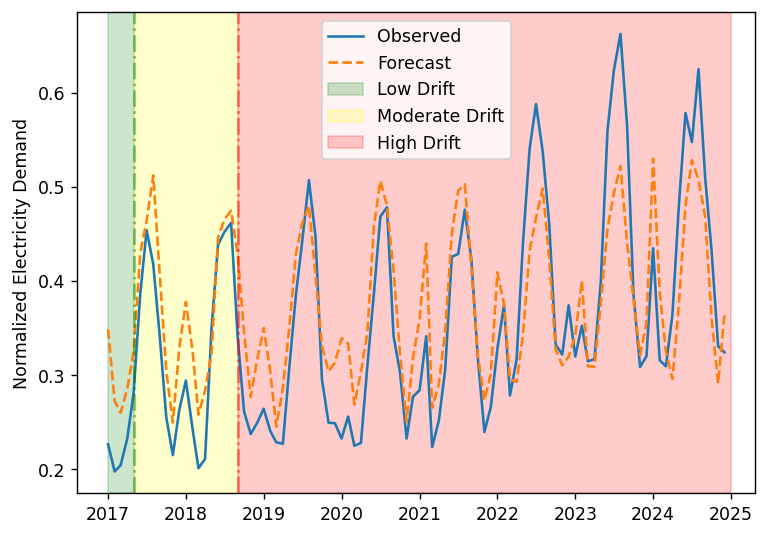

In [20]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(sampled_pred, label='Forecast', ls='--')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(pred_mlp.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_mlp.index[-1], color='red', alpha=0.2, label="High Drift")
# plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.legend()
plt.ylabel('Normalized Electricity Demand')
plt.legend()

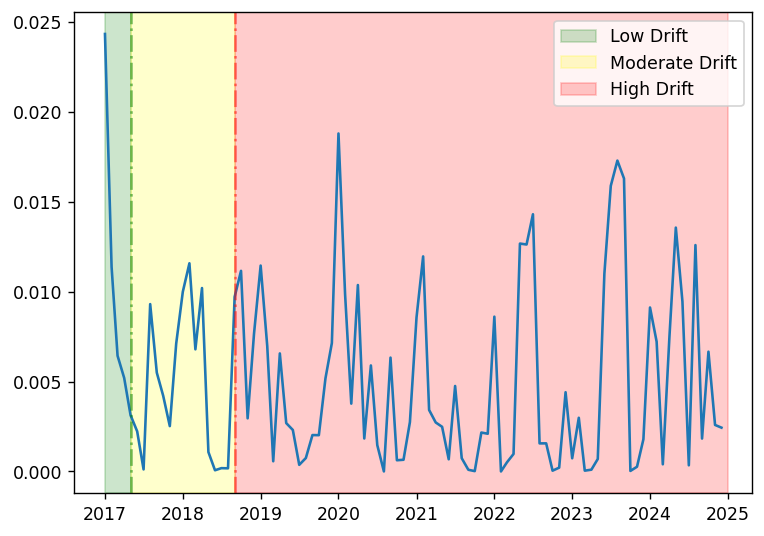

In [21]:
import matplotlib.pyplot as plt
plt.plot(diverge)
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(pred_mlp.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_mlp.index[-1], color='red', alpha=0.2, label="High Drift")
# plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.legend()